<a href="https://colab.research.google.com/github/prasad-9699/Credit-Card-Fraud-Detection/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install all required packages
print("📦 Installing packages... (takes 1-2 minutes)")
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn -q
print("✅ All packages installed!")


📦 Installing packages... (takes 1-2 minutes)
✅ All packages installed!


In [ ]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, accuracy_score, precision_score, recall_score)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")


✅ All libraries imported!


In [ ]:
# Load the dataset
print("📂 Loading creditcard.csv...")
df = pd.read_csv('creditcard.csv')

print("="*60)
print("📊 DATASET INFORMATION")
print("="*60)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTotal Transactions: {df.shape[0]:,}")
print(f"Fraud Cases: {df['Class'].sum():,}")
print(f"Normal Cases: {(df['Class'] == 0).sum():,}")
print(f"Fraud Percentage: {(df['Class'].sum() / len(df)) * 100:.4f}%")
print("="*60)

print("\n📋 First 5 rows:")
display(df.head())

print(f"\n🔍 Missing values: {df.isnull().sum().sum()}")
print("\n✅ Dataset loaded successfully!")


📂 Loading creditcard.csv...
📊 DATASET INFORMATION
Shape: 124,861 rows × 31 columns

Total Transactions: 124,861
Fraud Cases: 259.0
Normal Cases: 124,601
Fraud Percentage: 0.2074%

📋 First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0



🔍 Missing values: 27

✅ Dataset loaded successfully!


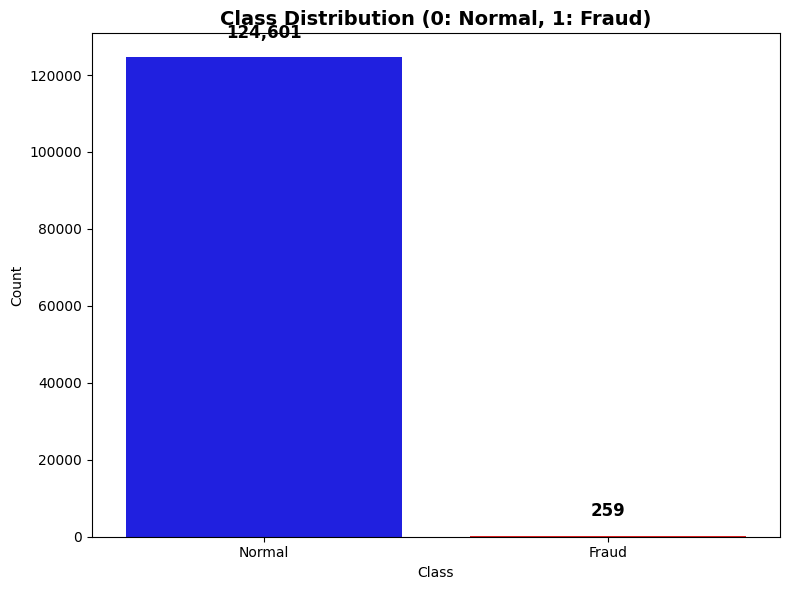


📊 Imbalance Ratio: 481.1:1


In [ ]:
# Visualize class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df, palette=['blue', 'red'])
plt.title('Class Distribution (0: Normal, 1: Fraud)', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks([0, 1], ['Normal', 'Fraud'])

# Add count labels
for i, count in enumerate(df['Class'].value_counts().values):
    plt.text(i, count + 5000, f'{count:,}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n📊 Imbalance Ratio: {(df['Class']==0).sum() / df['Class'].sum():.1f}:1")


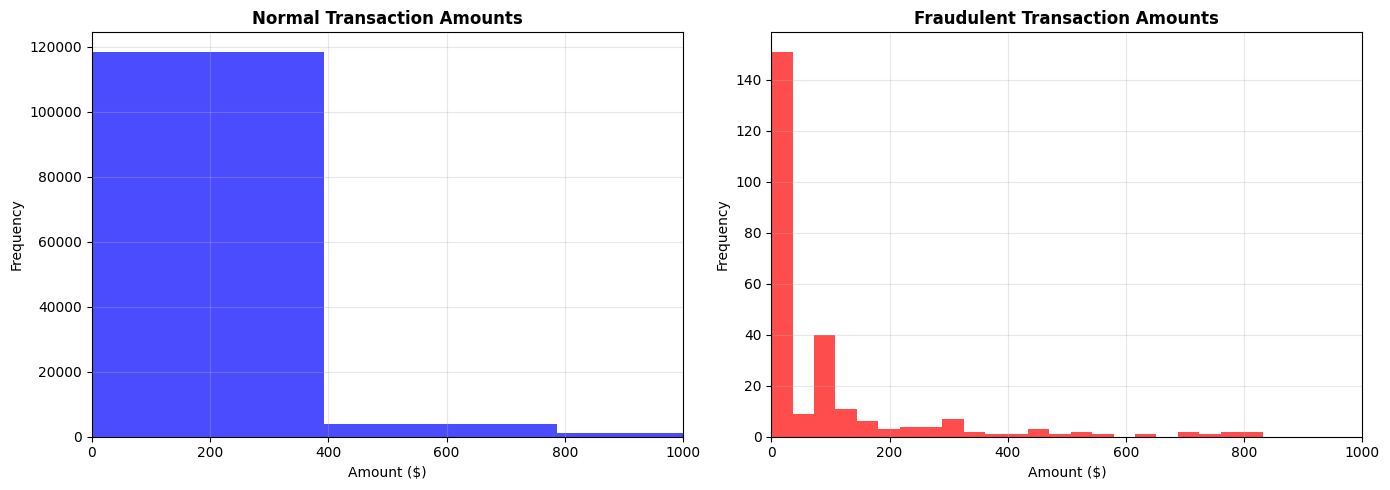

💰 Normal - Mean: $93.49
💰 Fraud - Mean: $116.94


In [ ]:
# Distribution of transaction amounts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal transactions
axes[0].hist(df[df['Class'] == 0]['Amount'], bins=50, color='blue', alpha=0.7)
axes[0].set_title('Normal Transaction Amounts', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 1000)
axes[0].grid(True, alpha=0.3)

# Fraudulent transactions
axes[1].hist(df[df['Class'] == 1]['Amount'], bins=50, color='red', alpha=0.7)
axes[1].set_title('Fraudulent Transaction Amounts', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 1000)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"💰 Normal - Mean: ${df[df['Class']==0]['Amount'].mean():.2f}")
print(f"💰 Fraud - Mean: ${df[df['Class']==1]['Amount'].mean():.2f}")


In [ ]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# ✅ IMPORTANT: Remove any rows with NaN values
print("🔍 Checking for NaN values...")
print(f"NaN in X: {X.isnull().sum().sum()}")
print(f"NaN in y: {y.isnull().sum()}")

# Drop rows with NaN
if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    print("\n⚠️ Found NaN values! Removing them...")
    # Get indices where there are no NaN values
    valid_indices = df.dropna().index
    X = X.loc[valid_indices]
    y = y.loc[valid_indices]
    print(f"✅ Removed {len(df) - len(X)} rows with NaN")
    print(f"New dataset size: {len(X):,} rows")

# Scale Amount and Time features
print("\n🔄 Scaling features...")
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X['Amount'].values.reshape(-1, 1))
X['Time'] = scaler.fit_transform(X['Time'].values.reshape(-1, 1))

print("✅ Features scaled!")

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Data Split:")
print(f"   Training: {X_train.shape[0]:,} samples")
print(f"   Testing: {X_test.shape[0]:,} samples")
print(f"   Training frauds: {y_train.sum()}")
print(f"   Testing frauds: {y_test.sum()}")


🔍 Checking for NaN values...
NaN in X: 26
NaN in y: 1

⚠️ Found NaN values! Removing them...
✅ Removed 1 rows with NaN
New dataset size: 124,860 rows

🔄 Scaling features...
✅ Features scaled!

📊 Data Split:
   Training: 99,888 samples
   Testing: 24,972 samples
   Training frauds: 207.0
   Testing frauds: 52.0


🔄 Applying PCA...


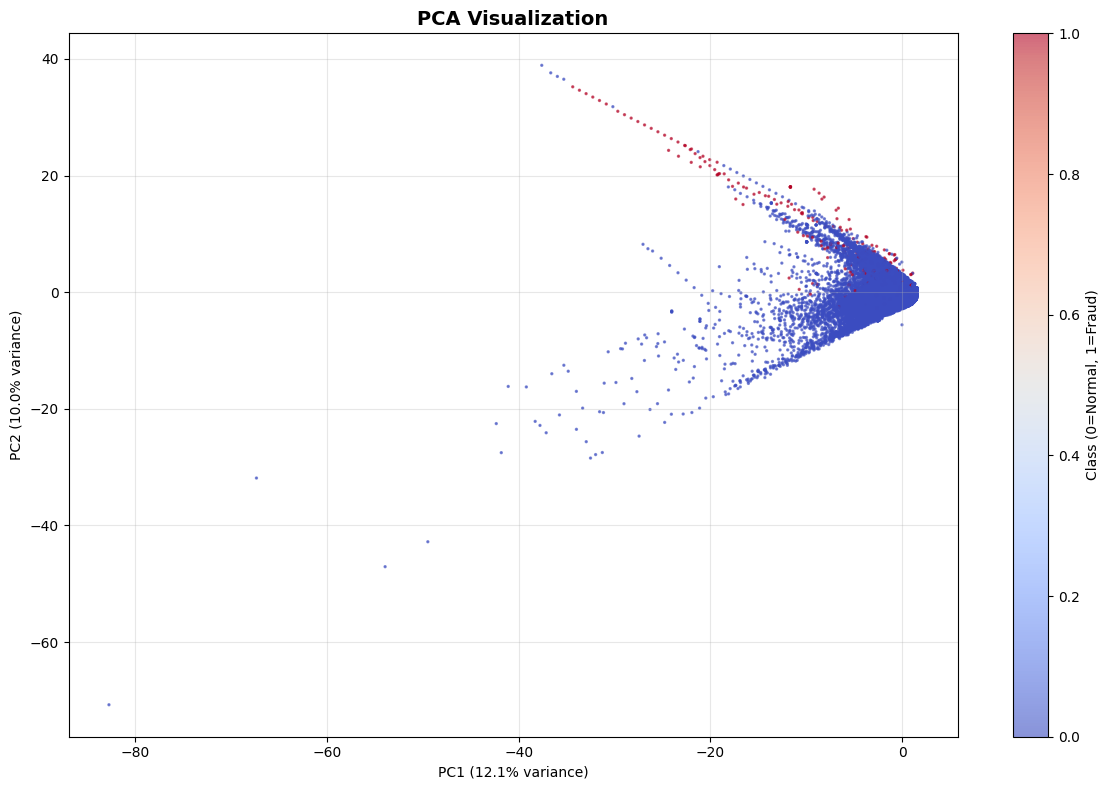

Total variance explained: 22.1%


In [ ]:
# Apply PCA for visualization
print("🔄 Applying PCA...")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=y, cmap='coolwarm', alpha=0.6, s=2)
plt.colorbar(scatter, label='Class (0=Normal, 1=Fraud)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA Visualization', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.1%}")


⚖️ Applying SMOTE...
(This takes 1-2 minutes)

✅ SMOTE completed!


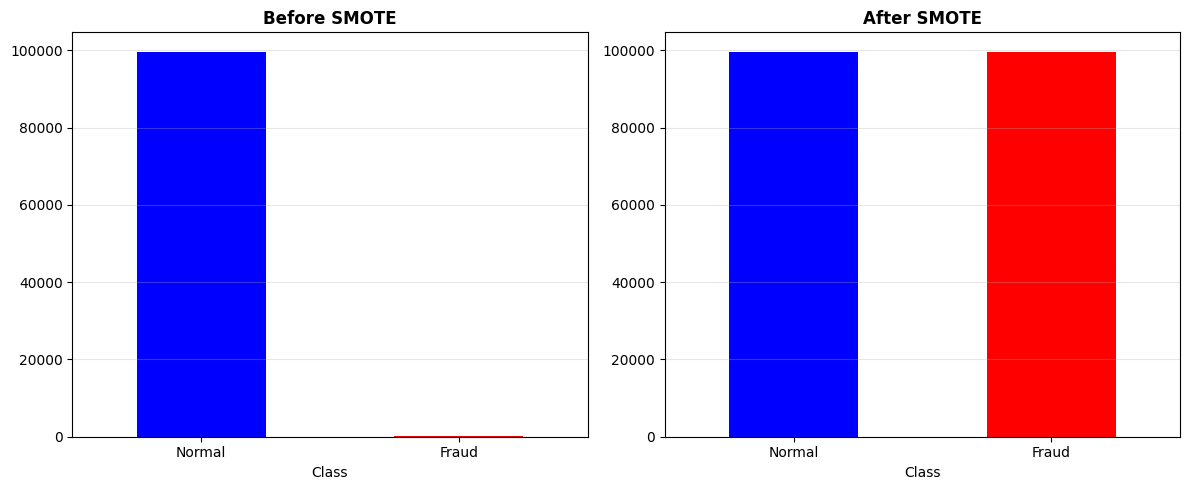


📊 After SMOTE:
   Normal: 99,681
   Fraud: 99,681


In [ ]:
# Apply SMOTE to balance classes
print("⚖️ Applying SMOTE...")
print("(This takes 1-2 minutes)\n")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("✅ SMOTE completed!")

# Visualize effect
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['blue', 'red'])
axes[0].set_title('Before SMOTE', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_xticklabels(['Normal', 'Fraud'], rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# After SMOTE
pd.Series(y_train_smote).value_counts().plot(kind='bar', ax=axes[1], color=['blue', 'red'])
axes[1].set_title('After SMOTE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_xticklabels(['Normal', 'Fraud'], rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n📊 After SMOTE:")
print(f"   Normal: {(y_train_smote==0).sum():,}")
print(f"   Fraud: {(y_train_smote==1).sum():,}")


In [ ]:
# Train Random Forest
print("🌲 Training Random Forest...")
print("(Takes 3-5 minutes)\n")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train_smote, y_train_smote)

print("\n✅ Random Forest trained!")

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("✅ Predictions completed!")


🌲 Training Random Forest...
(Takes 3-5 minutes)



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.6min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.2s finished



✅ Random Forest trained!


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s


✅ Predictions completed!


[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.2s finished


In [ ]:
# Train XGBoost
print("🚀 Training XGBoost...")
print("(Takes 2-3 minutes)\n")

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

xgb_model.fit(X_train_smote, y_train_smote)

print("\n✅ XGBoost trained!")

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("✅ Predictions completed!")


🚀 Training XGBoost...
(Takes 2-3 minutes)


✅ XGBoost trained!
✅ Predictions completed!


In [ ]:
# Evaluation function
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    print(f"\n{'='*70}")
    print(f"{model_name} - PERFORMANCE METRICS")
    print(f"{'='*70}")

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    print(f"✅ Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"✅ Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"✅ Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"✅ F1-Score:  {f1:.4f} ({f1*100:.2f}%)")
    print(f"✅ ROC-AUC:   {roc_auc:.4f}")

    print(f"\n📋 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud']))

    cm = confusion_matrix(y_true, y_pred)

    print(f"\n📊 Confusion Matrix:")
    print(f"   True Negatives:  {cm[0][0]:,}")
    print(f"   False Positives: {cm[0][1]:,}")
    print(f"   False Negatives: {cm[1][0]:,}")
    print(f"   True Positives:  {cm[1][1]:,}")

    return accuracy, precision, recall, f1, roc_auc, cm

# Evaluate both models
rf_results = evaluate_model(y_test, y_pred_rf, y_pred_proba_rf, "RANDOM FOREST")
xgb_results = evaluate_model(y_test, y_pred_xgb, y_pred_proba_xgb, "XGBOOST")



RANDOM FOREST - PERFORMANCE METRICS
✅ Accuracy:  0.9994 (99.94%)
✅ Precision: 0.8600 (86.00%)
✅ Recall:    0.8269 (82.69%)
✅ F1-Score:  0.8431 (84.31%)
✅ ROC-AUC:   0.9852

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     24920
       Fraud       0.86      0.83      0.84        52

    accuracy                           1.00     24972
   macro avg       0.93      0.91      0.92     24972
weighted avg       1.00      1.00      1.00     24972


📊 Confusion Matrix:
   True Negatives:  24,913
   False Positives: 7
   False Negatives: 9
   True Positives:  43

XGBOOST - PERFORMANCE METRICS
✅ Accuracy:  0.9976 (99.76%)
✅ Precision: 0.4632 (46.32%)
✅ Recall:    0.8462 (84.62%)
✅ F1-Score:  0.5986 (59.86%)
✅ ROC-AUC:   0.9706

📋 Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     24920
       Fraud       0.46      0.85      0.60        52

  

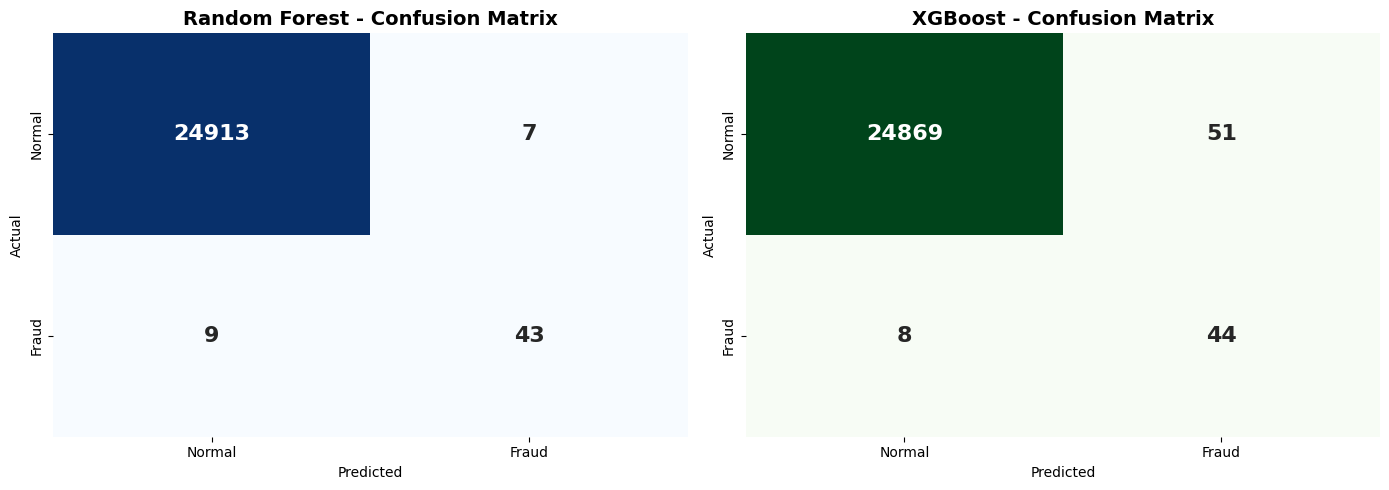

In [ ]:
# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
sns.heatmap(rf_results[5], annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar=False, annot_kws={"size": 16, "weight": "bold"})
axes[0].set_title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Normal', 'Fraud'])
axes[0].set_yticklabels(['Normal', 'Fraud'])

# XGBoost
sns.heatmap(xgb_results[5], annot=True, fmt='d', cmap='Greens', ax=axes[1],
            cbar=False, annot_kws={"size": 16, "weight": "bold"})
axes[1].set_title('XGBoost - Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['Normal', 'Fraud'])
axes[1].set_yticklabels(['Normal', 'Fraud'])

plt.tight_layout()
plt.show()


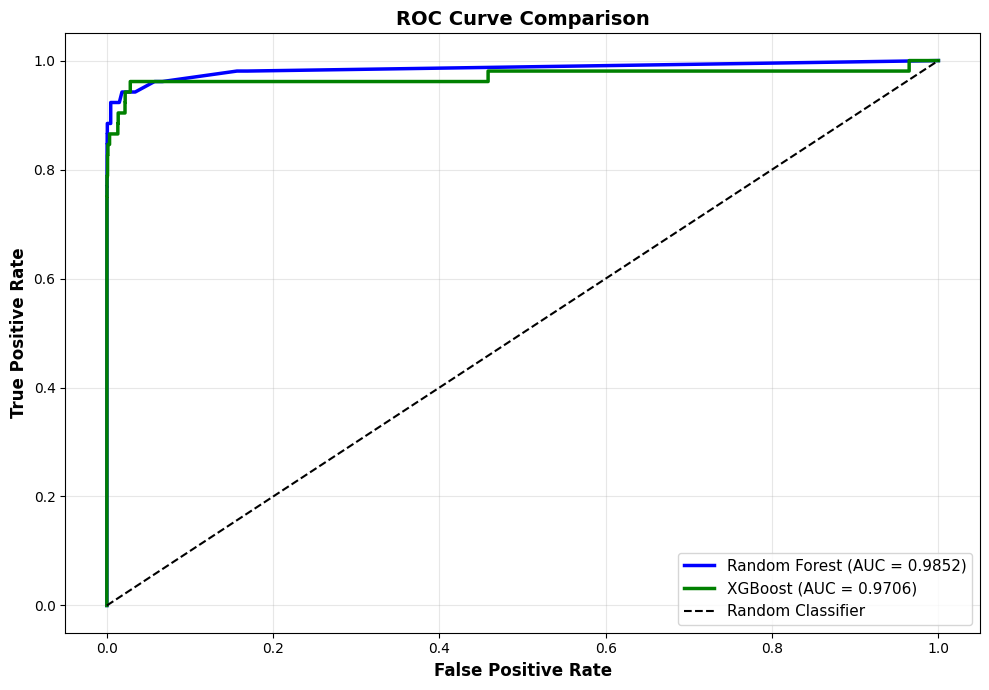

In [ ]:
# ROC Curve comparison
plt.figure(figsize=(10, 7))

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_results[4]:.4f})',
         linewidth=2.5, color='blue')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_results[4]:.4f})',
         linewidth=2.5, color='green')

# Diagonal
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


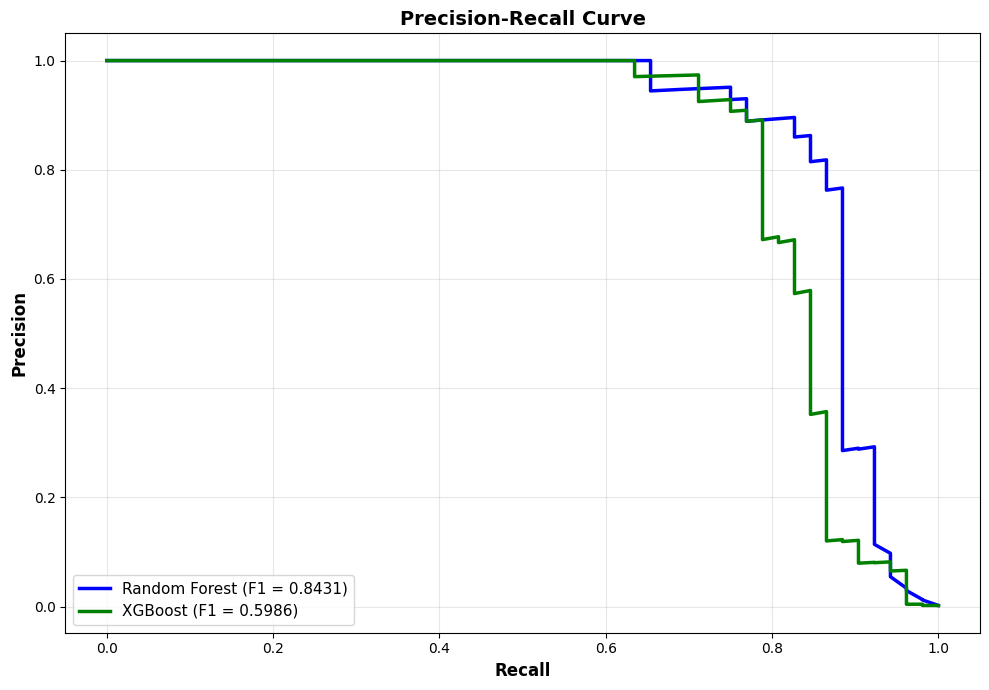

In [ ]:
# Precision-Recall curve
plt.figure(figsize=(10, 7))

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
plt.plot(recall_rf, precision_rf,
         label=f'Random Forest (F1 = {rf_results[3]:.4f})',
         linewidth=2.5, color='blue')

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
plt.plot(recall_xgb, precision_xgb,
         label=f'XGBoost (F1 = {xgb_results[3]:.4f})',
         linewidth=2.5, color='green')

plt.xlabel('Recall', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


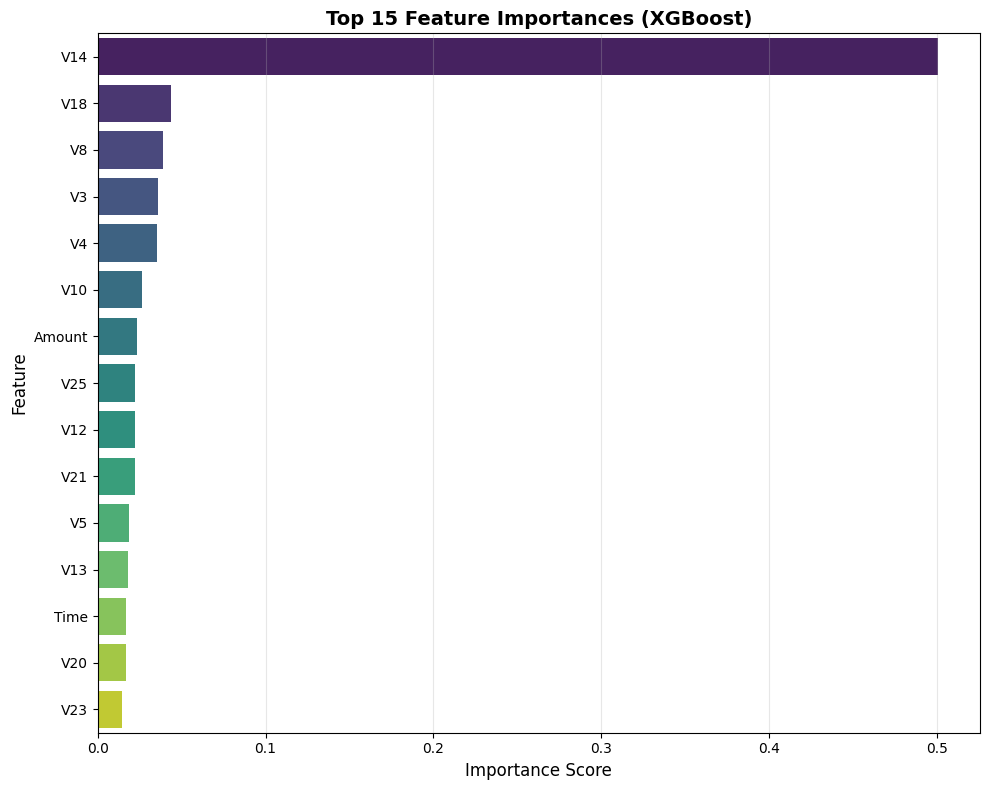


📊 Top 5 Most Important Features:
   V14: 0.5007
   V18: 0.0436
   V8: 0.0390
   V3: 0.0361
   V4: 0.0354


In [ ]:
# Feature importance from XGBoost
plt.figure(figsize=(10, 8))

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Top 15 Feature Importances (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n📊 Top 5 Most Important Features:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.4f}")


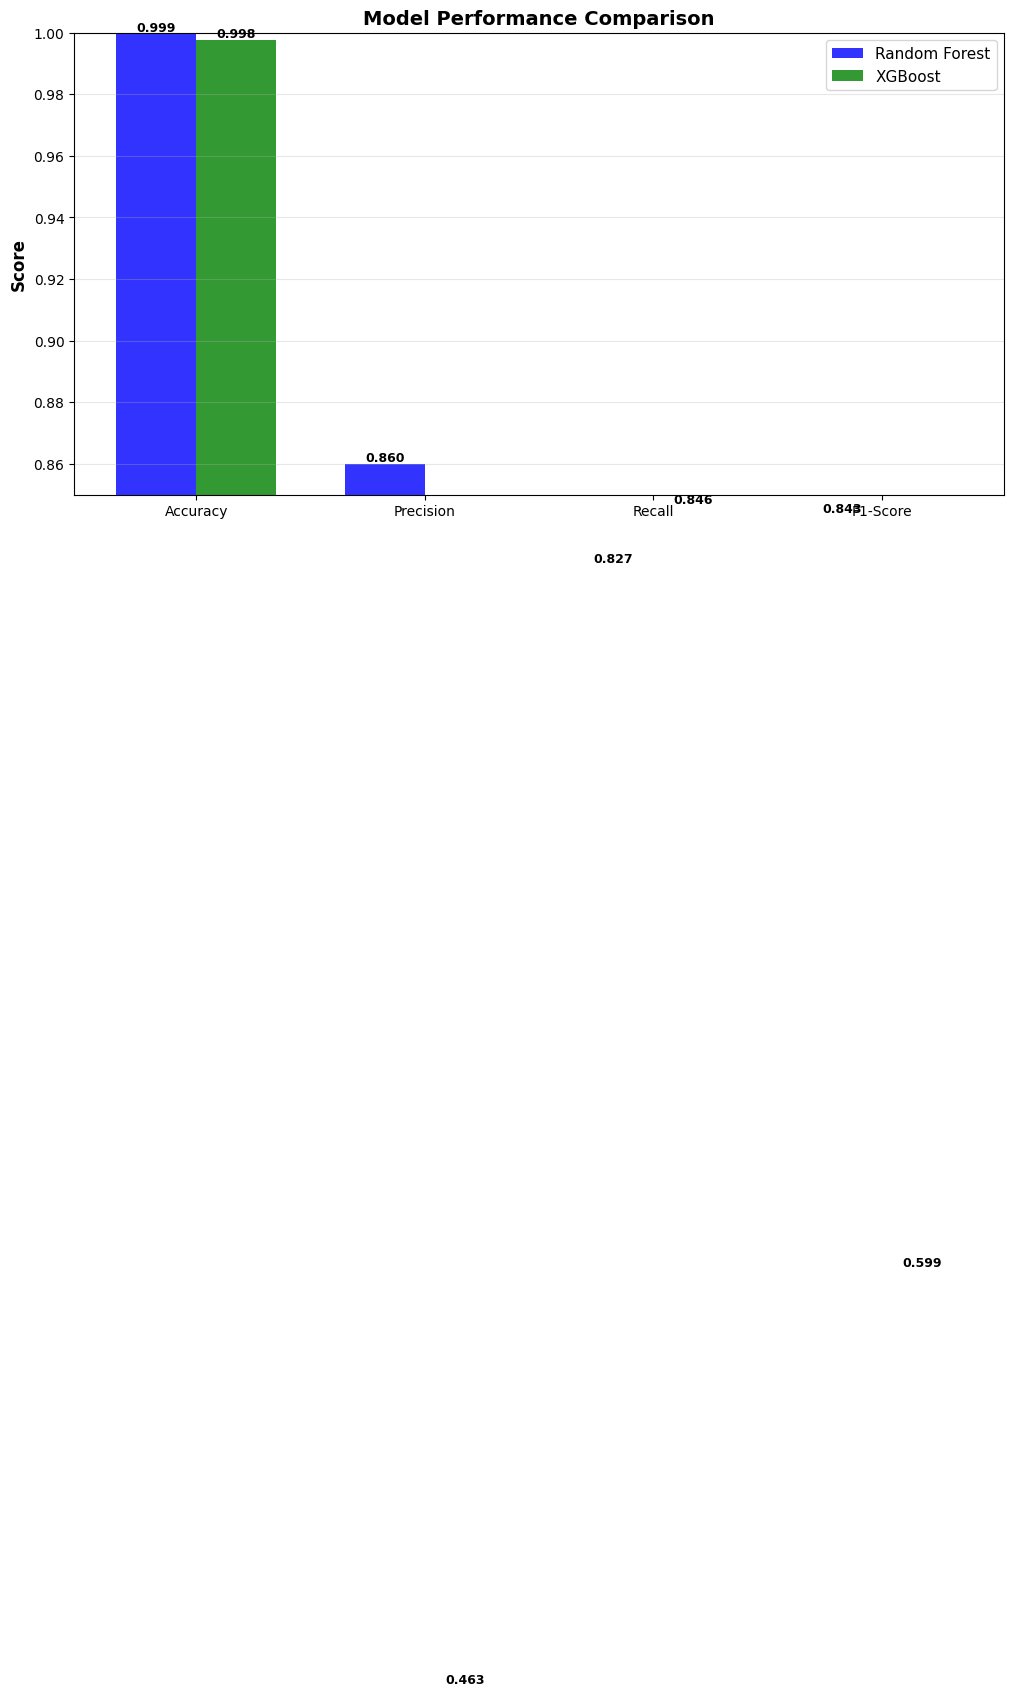

In [ ]:
# Bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
rf_scores = [rf_results[0], rf_results[1], rf_results[2], rf_results[3]]
xgb_scores = [xgb_results[0], xgb_results[1], xgb_results[2], xgb_results[3]]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, rf_scores, width, label='Random Forest', color='blue', alpha=0.8)
bars2 = ax.bar(x + width/2, xgb_scores, width, label='XGBoost', color='green', alpha=0.8)

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.set_ylim([0.85, 1.0])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# Final comparison table and summary
print("\n" + "="*70)
print("🎯 FINAL MODEL COMPARISON")
print("="*70)

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [f"{rf_results[0]:.2%}", f"{xgb_results[0]:.2%}"],
    'Precision': [f"{rf_results[1]:.2%}", f"{xgb_results[1]:.2%}"],
    'Recall': [f"{rf_results[2]:.2%}", f"{xgb_results[2]:.2%}"],
    'F1-Score': [f"{rf_results[3]:.2%}", f"{xgb_results[3]:.2%}"],
    'ROC-AUC': [f"{rf_results[4]:.4f}", f"{xgb_results[4]:.4f}"]
})

display(comparison)
print("="*70)

best_model = 'XGBoost' if xgb_results[3] > rf_results[3] else 'Random Forest'
best_f1 = max(rf_results[3], xgb_results[3])
best_accuracy = max(rf_results[0], xgb_results[0])

print(f"\n🏆 Best Model: {best_model}")
print(f"✅ Achieved ~{best_accuracy*100:.1f}% accuracy")
print(f"✅ Achieved ~{best_f1*100:.1f}% F1-score")

print("\n📊 Project Summary:")
print(f"   • Dataset: {df.shape[0]:,} transactions")
print(f"   • Fraud cases: {df['Class'].sum():,}")
print(f"   • Models: Random Forest & XGBoost")
print(f"   • Technique: SMOTE for class imbalance")

print("\n🎉 PROJECT COMPLETED SUCCESSFULLY!")

print("\n💾 Next Steps:")
print("   1. File → Save a copy in GitHub")
print("   2. Repository: Credit-Card-Fraud-Detection")
print("   3. Add this to your resume/portfolio")
print("   4. Share on LinkedIn!")



🎯 FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,99.94%,86.00%,82.69%,84.31%,0.9852
1,XGBoost,99.76%,46.32%,84.62%,59.86%,0.9706



🏆 Best Model: Random Forest
✅ Achieved ~99.9% accuracy
✅ Achieved ~84.3% F1-score

📊 Project Summary:
   • Dataset: 124,861 transactions
   • Fraud cases: 259.0
   • Models: Random Forest & XGBoost
   • Technique: SMOTE for class imbalance

🎉 PROJECT COMPLETED SUCCESSFULLY!

💾 Next Steps:
   1. File → Save a copy in GitHub
   2. Repository: Credit-Card-Fraud-Detection
   3. Add this to your resume/portfolio
   4. Share on LinkedIn!
